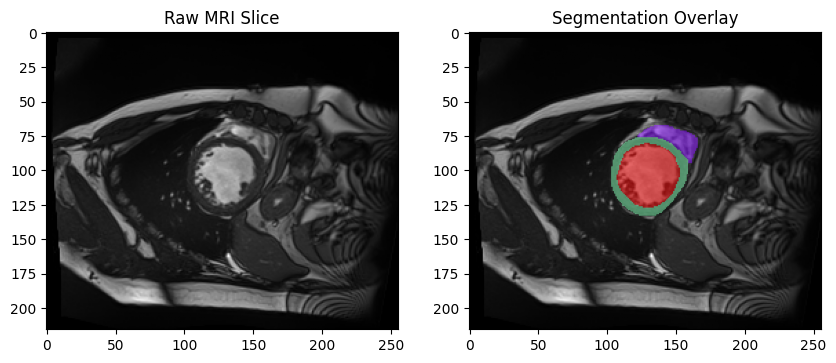

In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# 1. Added prefix 'r' to paths to treat backslashes as raw text
img_path = r"C:\Users\NITRO V 15\Downloads\archive (3)\database\training\patient001\patient001_frame01.nii"
gt_path = r"C:\Users\NITRO V 15\Downloads\archive (3)\database\training\patient001\patient001_frame01_gt.nii"

# Load MRI and mask
img = nib.load(img_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

# Select slice index to display (e.g., slice 5)
slice_idx = 5

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[:, :, slice_idx], cmap='gray')
axes[0].set_title("Raw MRI Slice")

# Overlay mask (labels: 1 = RV, 2 = MYO, 3 = LV)
axes[1].imshow(img[:, :, slice_idx], cmap='gray')
masked_gt = np.ma.masked_where(gt[:, :, slice_idx] == 0, gt[:, :, slice_idx])
axes[1].imshow(masked_gt, cmap='rainbow', alpha=0.5)
axes[1].set_title("Segmentation Overlay")

plt.show()
plt.show()

In [2]:
import os
import glob
import numpy as np

def parse_cfg(path):
    data = {}
    if not os.path.exists(path):
        return None
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, val = line.split(':', 1)
            data[key.strip()] = val.strip()
    return data

def main():
    base_dir = r"C:\Users\NITRO V 15\Downloads\archive (3)\database"
    print("ACDC Dataset Exploration and Summary\n" + "="*40)
    
    # Try importing nibabel
    try:
        import nibabel as nib
        has_nib = True
    except ImportError:
        has_nib = False
        print("nibabel is not installed. Voxel-level information will be limited.")

    for split in ['training', 'testing']:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            continue
            
        patients = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        patients.sort()
        
        shapes = []
        spacings = []
        slice_thicknesses = []
        unique_labels = set()
        label_counts = {0: 0, 1: 0, 2: 0, 3: 0}
        
        if has_nib:
            # Sample a few patients to avoid taking too much time
            sampled_patients = patients[:10]
            for p in sampled_patients:
                p_dir = os.path.join(split_dir, p)
                cfg = parse_cfg(os.path.join(p_dir, "Info.cfg"))
                if not cfg:
                    continue
                ed_str = cfg.get("ED").zfill(2)
                es_str = cfg.get("ES").zfill(2)
                
                # Check ground truth masks
                for frame_suffix in [f"frame{ed_str}", f"frame{es_str}"]:
                    gt_file = os.path.join(p_dir, f"{p}_{frame_suffix}_gt.nii")
                    if os.path.exists(gt_file):
                        img = nib.load(gt_file)
                        shapes.append(img.shape)
                        zooms = img.header.get_zooms()
                        spacings.append(zooms[:2])
                        slice_thicknesses.append(zooms[2])
                        
                        data = img.get_fdata()
                        uniques, counts = np.unique(data, return_counts=True)
                        for u, c in zip(uniques, counts):
                            val = int(round(u))
                            unique_labels.add(val)
                            if val in label_counts:
                                label_counts[val] += c
                                
        print(f"\n--- {split.upper()} SPLIT DETAILS ---")
        print(f"Total Patients: {len(patients)}")
        
        # Get overall diagnostics
        groups = {}
        for p in patients:
            cfg = parse_cfg(os.path.join(split_dir, p, "Info.cfg"))
            if cfg:
                grp = cfg.get("Group", "Unknown")
                groups[grp] = groups.get(grp, 0) + 1
        print(f"Pathology Distribution: {groups}")
        
        if has_nib and shapes:
            shapes_arr = np.array(shapes)
            spacings_arr = np.array(spacings)
            
            print("\nImage Resolution & Voxel Size Statistics (sampled first 10 patients):")
            print(f"  Shape (height, width, slices):")
            print(f"    Min shape: {shapes_arr.min(axis=0)}")
            print(f"    Max shape: {shapes_arr.max(axis=0)}")
            print(f"    Mean shape: {np.round(shapes_arr.mean(axis=0), 1)}")
            
            print(f"  Voxel Spacing (in-plane x, y in mm):")
            print(f"    Min spacing: {spacings_arr.min(axis=0)}")
            print(f"    Max spacing: {spacings_arr.max(axis=0)}")
            print(f"    Mean spacing: {np.round(spacings_arr.mean(axis=0), 3)}")
            
            print(f"  Slice Thickness (z-spacing in mm):")
            print(f"    Min thickness: {min(slice_thicknesses)}")
            print(f"    Max thickness: {max(slice_thicknesses)}")
            print(f"    Mean thickness: {np.round(np.mean(slice_thicknesses), 2)}")
            
            print(f"  Unique label values in Ground Truth: {sorted(list(unique_labels))}")
            total_voxels = sum(label_counts.values())
            if total_voxels > 0:
                print("  Voxel distribution in Ground Truth (as % of total):")
                print(f"    Background (Label 0): {label_counts.get(0, 0)/total_voxels*100:.2f}%")
                print(f"    Right Ventricle Cavity (Label 1): {label_counts.get(1, 0)/total_voxels*100:.2f}%")
                print(f"    Myocardium (Label 2): {label_counts.get(2, 0)/total_voxels*100:.2f}%")
                print(f"    Left Ventricle Cavity (Label 3): {label_counts.get(3, 0)/total_voxels*100:.2f}%")

if __name__ == "__main__":
    main()

ACDC Dataset Exploration and Summary

--- TRAINING SPLIT DETAILS ---
Total Patients: 100
Pathology Distribution: {'DCM': 20, 'HCM': 20, 'MINF': 20, 'NOR': 20, 'RV': 20}

Image Resolution & Voxel Size Statistics (sampled first 10 patients):
  Shape (height, width, slices):
    Min shape: [200 216  10]
    Max shape: [256 256  11]
    Mean shape: [226.2 248.8  10.1]
  Voxel Spacing (in-plane x, y in mm):
    Min spacing: [1.3671875 1.3671875]
    Max spacing: [1.875 1.875]
    Mean spacing: [1.539 1.539]
  Slice Thickness (z-spacing in mm):
    Min thickness: 10.0
    Max thickness: 10.0
    Mean thickness: 10.0
  Unique label values in Ground Truth: [0, 1, 2, 3]
  Voxel distribution in Ground Truth (as % of total):
    Background (Label 0): 95.56%
    Right Ventricle Cavity (Label 1): 1.03%
    Myocardium (Label 2): 1.42%
    Left Ventricle Cavity (Label 3): 1.99%

--- TESTING SPLIT DETAILS ---
Total Patients: 50
Pathology Distribution: {'DCM': 10, 'NOR': 10, 'MINF': 10, 'HCM': 10, 'RV'

In [3]:
import os
import nibabel as nib
import pandas as pd

def parse_cfg(path):
    data = {}
    if not os.path.exists(path):
        return None
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, val = line.split(':', 1)
            data[key.strip()] = val.strip()
    return data

def main():
    base_dir = r"C:\Users\NITRO V 15\Downloads\archive (3)\database"
    records = []
    
    for split in ['training', 'testing']:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            continue
            
        patients = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        patients.sort()
        
        for p in patients:
            p_dir = os.path.join(split_dir, p)
            cfg_path = os.path.join(p_dir, "Info.cfg")
            cfg = parse_cfg(cfg_path)
            
            # Read 4D file header to get dimensions
            nii_4d_path = os.path.join(p_dir, f"{p}_4d.nii")
            h, w, d, t = "N/A", "N/A", "N/A", "N/A"
            spacing_x, spacing_y, spacing_z = "N/A", "N/A", "N/A"
            
            if os.path.exists(nii_4d_path):
                try:
                    img = nib.load(nii_4d_path)
                    shape = img.shape
                    if len(shape) == 4:
                        h, w, d, t = shape
                    elif len(shape) == 3:
                        h, w, d = shape
                        t = 1
                    zooms = img.header.get_zooms()
                    spacing_x, spacing_y = round(zooms[0], 3), round(zooms[1], 3)
                    if len(zooms) >= 3:
                        spacing_z = round(zooms[2], 3)
                except Exception as e:
                    print(f"Error loading {nii_4d_path}: {e}")
            
            records.append({
                "Patient ID": p,
                "Split": split.capitalize(),
                "Pathology Group": cfg.get("Group", "N/A") if cfg else "N/A",
                "Resolution (H x W)": f"{h} x {w}",
                "Slices (D)": d,
                "Frames (T)": t,
                "Voxel Spacing (X x Y x Z mm)": f"{spacing_x} x {spacing_y} x {spacing_z}",
                "ED Frame": cfg.get("ED", "N/A") if cfg else "N/A",
                "ES Frame": cfg.get("ES", "N/A") if cfg else "N/A",
                "Weight (kg)": cfg.get("Weight", "N/A") if cfg else "N/A",
                "Height (cm)": cfg.get("Height", "N/A") if cfg else "N/A"
            })
            
    df = pd.DataFrame(records)
    
    # Save as Markdown
    output_dir = r"C:\D\ACDC\data-exploration"
    os.makedirs(output_dir, exist_ok=True)
    markdown_path = os.path.join(output_dir, "acdc_full_dataset_inventory.md")
    
    with open(markdown_path, 'w') as f:
        f.write("# ACDC Dataset - Full Inventory\n\n")
        f.write("This document lists the parameters, dimensions, and diagnostic groupings for all **150 patients** in the ACDC dataset.\n\n")
        f.write(df.to_markdown(index=False))
        
    print(f"Inventory saved successfully to: {markdown_path}")

if __name__ == "__main__":
    main()

Inventory saved successfully to: C:\D\ACDC\data-exploration\acdc_full_dataset_inventory.md
